# NN Dataset Generation for TAG Authentication (v3 — CNN Input)

**Objective**: Generate dataset for 1D CNN authentication using raw equalized signal y/h.

- **DNN input (y_eq)**: equalized signal vector y/h of length L_FIXED=1024 (zero-padded)
- **Classical input (tau_eq)**: correlator scalar |Σ(y/h − ρ_s·msg)·tag_ref| / ρ_t (Xie 2021)
- **Labels**: H1=1 (authentic — message WITH legitimate TAG) vs H0=0 (unauthenticated — message WITHOUT TAG)
- **SNR range**: 0–30 dB stratified (matches Xie 2021 Fig. 2)
- **Output**: HDF5 with y_eq, tau_eq, h, snr, labels — split 80/10/10

**Signal model**:
- H1: y = h·(ρ_s·msg + ρ_t·tag) + w  →  y/h = ρ_s·msg + ρ_t·tag + w/h  
- H0: y = h·(msg) + w            →  y/h = msg + w/h  (no TAG)

**Architecture reference**: Chin & Chin (Eng. Proc. 2025) — 1D CNN for binary hypothesis testing  
**Theory**: Braca et al. (2022) — D3F framework, ML converges to LRT under large-deviations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc, erfcinv
from scipy import stats
import h5py
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"Python version: {np.__version__}")
print(f"NumPy version: {np.__version__}")

# ============================================================================
# SETUP PATHS FOR NEW DIRECTORY STRUCTURE
# ============================================================================
from pathlib import Path

notebook_dir = Path.cwd()  # Current: notebooks/
project_root = notebook_dir.parent  # Go up to: Redes Neurais/
results_dir = project_root / "results"
data_dir = results_dir / "data"
visualizations_dir = results_dir / "visualizations"

# Ensure directories exist
data_dir.mkdir(parents=True, exist_ok=True)
visualizations_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")
print(f"Visualizations directory: {visualizations_dir}")


Libraries imported successfully!
Python version: 2.4.4
NumPy version: 2.4.4
Project root: c:\Users\thami\OneDrive\Documents\TAG-Authentication\Redes Neurais
Data directory: c:\Users\thami\OneDrive\Documents\TAG-Authentication\Redes Neurais\results\data
Visualizations directory: c:\Users\thami\OneDrive\Documents\TAG-Authentication\Redes Neurais\results\visualizations


In [2]:
# ==============================================================================
# 2. CORE FUNCTIONS FOR TAG GENERATION & SIMULATION
# ==============================================================================

def modulator_bpsk(L, seed=None):
    if seed is not None:
        np.random.seed(seed)
    bits = np.random.randint(0, 2, L)
    return 2 * bits - 1  # {+1, -1}

def _tent(x, beta=1e-6):
    """Tent map on [-1, 1].
    Invariant measure: Uniform[-1,1]  →  E[x]=0, E[x²]=1/3.
    Matches Monte Carlo notebook implementation.
    """
    if x < beta:
        return 2.0 / (beta + 1) * x + (1.0 - beta) / (beta + 1)
    return 2.0 / (beta - 1) * x - (beta + 1) / (beta - 1)

def generate_tag(msg, key, L, K=512):
    """Generate chaotic TAG.  E[tag]=0, E[tag²]≈1/3  (matches MC notebook).

    Bugs fixed vs. original:
      1. seed = sum(msg*key) % 1 was always 0.0  (integer sum mod 1)
         → now uses XOR-bits → 64-bit int → quadratic map → [-1,1]
      2. Tent map was defined on [0,1]: from x=0 it diverged to -inf
         → replaced with MC tent map on [-1,1], zero-mean orbit
    """
    # Step 1 — seed: msg ±1 → bits, XOR with key, pack 64 bits → scalar in [-1,1]
    msg_bits = ((msg + 1) // 2).astype(np.uint8)          # ±1 → {0,1}
    n        = min(K, len(msg_bits), len(key))
    m_pad    = np.resize(msg_bits[:n], K)
    k_pad    = np.resize(key[:n].astype(np.uint8), K)
    xor_seq  = np.bitwise_xor(m_pad, k_pad)

    packed   = np.packbits(xor_seq[:64])                   # 64 bits → 8 bytes
    xor_int  = int.from_bytes(packed.tobytes(), 'big')
    xi       = (6 * xor_int**2 + xor_int + 1) % (2**64)
    x0       = (xi / (2**64 - 1)) * 2.0 - 1.0             # seed ∈ (-1, 1)

    # Step 2 — chaotic orbit on [-1,1]: discard warm_up, collect L points
    warm_up = max(0, K - L)
    x = x0
    buf = np.empty(L, dtype=np.float64)
    k_out = 0
    for i in range(warm_up + L):
        x = _tent(x)
        if i >= warm_up:
            buf[k_out] = x
            k_out += 1

    # Step 3 — normalize: var(buf)=1/3  →  E[tag²]=1/3 (since E[tag]≈0)
    std_buf = buf.std()
    if std_buf > 1e-10:
        buf = buf / (std_buf * np.sqrt(3))

    return buf

def rayleigh_channel(length, sigma_h=1/np.sqrt(2)):
    real_part = np.random.normal(0, sigma_h, length)
    imag_part = np.random.normal(0, sigma_h, length)
    return np.sqrt(real_part**2 + imag_part**2)

def awgn_channel(signal, snr_db):
    snr_linear  = 10**(snr_db / 10)
    signal_power = np.mean(np.abs(signal)**2)
    noise_power  = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
    return signal + noise

# --- Quick validation ---
np.random.seed(0)
_msg = modulator_bpsk(1024)
_key = np.random.randint(0, 2, 512)
_tag = generate_tag(_msg, _key, 1024, K=512)
print(f"Tag validation (L=1024, K=512):")
print(f"  mean  = {_tag.mean():.4f}  (expect ≈ 0)")
print(f"  var   = {_tag.var():.4f}  (expect ≈ 0.333)")
print(f"  E[t²] = {np.mean(_tag**2):.4f}  (expect ≈ 0.333)")
print(f"  min/max = {_tag.min():.3f} / {_tag.max():.3f}")
print("Core functions defined successfully!")


Tag validation (L=1024, K=512):
  mean  = -0.0487  (expect ≈ 0)
  var   = 0.3333  (expect ≈ 0.333)
  E[t²] = 0.3357  (expect ≈ 0.333)
  min/max = -0.953 / 0.954
Core functions defined successfully!


In [3]:
# ==============================================================================
# 2b. GPU-ACCELERATED BATCH GENERATION
# ==============================================================================
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

BATCH_SIZE = 4096   # samples generated per GPU call; tune to fill VRAM

# ------------------------------------------------------------------
# Seed computation (CPU — involves 64-bit Python big-int arithmetic)
# ------------------------------------------------------------------
def _compute_seed(msg, key, K):
    """Single seed ∈ (-1,1) from msg ±1 and binary key."""
    msg_bits = ((msg + 1) // 2).astype(np.uint8)
    n       = min(K, len(msg_bits), len(key))
    m_pad   = np.resize(msg_bits[:n], K)
    k_pad   = np.resize(key[:n].astype(np.uint8), K)
    xor_seq = np.bitwise_xor(m_pad, k_pad)
    packed  = np.packbits(xor_seq[:64])
    xor_int = int.from_bytes(packed.tobytes(), 'big')
    xi      = (6 * xor_int**2 + xor_int + 1) % (2**64)
    return (xi / (2**64 - 1)) * 2.0 - 1.0   # ∈ (-1, 1)

# ------------------------------------------------------------------
# Batch orbit generation on GPU (or vectorised numpy fallback)
# ------------------------------------------------------------------
def generate_tags_batch(seeds, L, K=512):
    """Generate N tags in parallel.

    seeds : (N,) array  — one seed per sample, each ∈ (-1, 1)
    L     : int         — tag / message length
    Returns (N, L) float32 array with E[tag²] ≈ 1/3 per row.

    GPU path  : each tent-map step is a vectorised op on N-element tensor.
    CPU path  : same logic with numpy (still much faster than per-sample loop).
    """
    beta    = 1e-6
    warm_up = max(0, K - L)

    if device.type == 'cuda':
        x   = torch.tensor(seeds, dtype=torch.float32, device=device)
        buf = torch.empty(len(seeds), L, device=device)
        k   = 0
        for i in range(warm_up + L):
            x = torch.where(x < beta,
                            2.0/(beta+1)*x + (1.0-beta)/(beta+1),
                            2.0/(beta-1)*x - (beta+1)/(beta-1))
            if i >= warm_up:
                buf[:, k] = x;  k += 1
        std = buf.std(dim=1, keepdim=True).clamp(min=1e-10)
        return (buf / (std * np.sqrt(3))).cpu().numpy().astype(np.float32)
    else:
        x   = np.asarray(seeds, dtype=np.float64)
        buf = np.empty((len(seeds), L), dtype=np.float64)
        k   = 0
        for i in range(warm_up + L):
            x = np.where(x < beta,
                         2.0/(beta+1)*x + (1.0-beta)/(beta+1),
                         2.0/(beta-1)*x - (beta+1)/(beta-1))
            if i >= warm_up:
                buf[:, k] = x;  k += 1
        std = buf.std(axis=1, keepdims=True)
        std[std < 1e-10] = 1.0
        return (buf / (std * np.sqrt(3))).astype(np.float32)

# ------------------------------------------------------------------
# Quick throughput benchmark
# ------------------------------------------------------------------
import time
_seeds_test = np.random.uniform(-1, 1, 256)
_t0 = time.perf_counter()
_warmup_result = generate_tags_batch(_seeds_test, L=1024, K=512)
if device.type == 'cuda': torch.cuda.synchronize()
_dt = time.perf_counter() - _t0
print(f"\nBatch throughput (256 tags, L=1024): {_dt*1000:.1f} ms  →  {256/_dt:.0f} tags/s")
print(f"Estimated full dataset ({350_000} samples): {350_000/(_dt/256)/60:.1f} min")


Device : cuda
GPU    : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM   : 6.0 GB

Batch throughput (256 tags, L=1024): 376.9 ms  →  679 tags/s
Estimated full dataset (350000 samples): 3961855.1 min


In [4]:
# ==============================================================================
# 3. SAMPLE GENERATION — y/h vector + tau_eq scalar (Xie 2021)
# ==============================================================================

L_FIXED = 1024
RHO_S   = np.sqrt(0.985)
# rho_t satisfies the power constraint: rho_s² + rho_t² * E[tag²] = 1
# Tag has E[tag²] ≈ 1/3  →  rho_t = sqrt((1 - rho_s²) / (1/3)) = sqrt(3*(1-rho_s²))
RHO_T   = np.sqrt(3 * (1 - RHO_S**2))   # ≈ 0.212  (was 0.124 — wrong, assumed E[tag²]=1)

print(f"RHO_S = {RHO_S:.6f}  (rho_s² = {RHO_S**2:.4f})")
print(f"RHO_T = {RHO_T:.6f}  (rho_t² * 1/3 = {RHO_T**2/3:.4f})")
print(f"Power check: rho_s² + rho_t²·E[tag²] = {RHO_S**2 + RHO_T**2*(1/3):.6f}  (should be 1.0)")

def generate_sample(snr_db, L, K=512, is_authentic=True):
    """Return one training sample for the 1D CNN pipeline.

    H1 (authentic):      y = h·(ρ_s·msg + ρ_t·tag) + w  →  y/h = ρ_s·msg + ρ_t·tag + w/h
    H0 (unauthenticated): y = h·msg + w                  →  y/h = msg + w/h  (no TAG, attacker sends raw BPSK)

    Classical correlator τ = Σ(y/h − ρ_s·msg)·tag_ref / ρ_t  (signed, Xie 2021 Eq. 5)
      H0: τ ~ N(0, σ²)           (only noise × tag correlation)
      H1: τ ~ N(L·E[tag²], σ²)  (TAG signal + noise)

    Returns
    -------
    y_eq_pad : float32 ndarray (L_FIXED,)
    tau_eq   : float32   signed correlator
    h        : float32
    snr_db   : float32
    label    : int  1=H1, 0=H0
    """
    msg     = modulator_bpsk(L)
    key     = np.random.randint(0, 2, L)
    tag_ref = generate_tag(msg, key, L, K)

    h = rayleigh_channel(1)[0]
    h = max(h, 1e-6)

    if is_authentic:
        x = RHO_S * msg + RHO_T * tag_ref
        y = awgn_channel(h * x, snr_db)
    else:
        x = msg          # attacker sends raw BPSK (no rho_s scaling, no tag)
        y = awgn_channel(h * x, snr_db)

    y_eq = y / h

    # Signed correlator — H0: N(0,σ²),  H1: N(L·E[tag²], σ²)
    tau_eq = float(np.sum((y_eq - RHO_S * msg) * tag_ref) / RHO_T)

    y_eq_pad = np.zeros(L_FIXED, dtype=np.float32)
    y_eq_pad[:L] = y_eq.astype(np.float32)

    return y_eq_pad, np.float32(tau_eq), np.float32(h), np.float32(snr_db), int(is_authentic)


# Smoke test
_y,  _tau,  _h, _snr, _lbl  = generate_sample(10.0, 1024, is_authentic=True)
_y0, _tau0, _,  _,    _lbl0 = generate_sample(10.0, 1024, is_authentic=False)
print(f"\nSmoke test (SNR=10 dB, L=1024):")
print(f"  tau H1 = {_tau:.2f}   (expect ≈ L·E[tag²] ≈ {1024/3:.0f})")
print(f"  tau H0 = {_tau0:.2f}   (expect ≈ 0, can be negative)")


RHO_S = 0.992472  (rho_s² = 0.9850)
RHO_T = 0.212132  (rho_t² * 1/3 = 0.0150)
Power check: rho_s² + rho_t²·E[tag²] = 1.000000  (should be 1.0)

Smoke test (SNR=10 dB, L=1024):
  tau H1 = 311.76   (expect ≈ L·E[tag²] ≈ 341)
  tau H0 = -6.31   (expect ≈ 0, can be negative)


In [5]:
# ==============================================================================
# 4. STRATIFIED DATASET GENERATION  (GPU-accelerated batch)
# ==============================================================================
# Strategy: process BATCH_SIZE samples at once.
#   - Within a batch, all samples share the same L (randomly chosen per batch).
#   - Tags are generated in parallel on GPU via generate_tags_batch.
#   - Signal, noise, and correlator are fully vectorised with numpy.
# ==============================================================================

NUM_SAMPLES  = 300_000
SNR_RANGE    = (0, 30)
L_RANGE      = (512, 1024)
SNR_BINS     = 6
K_KEY        = 512

snr_edges    = np.linspace(SNR_RANGE[0], SNR_RANGE[1], SNR_BINS + 1)
base_per_bin = NUM_SAMPLES // SNR_BINS

# Pre-allocate
total_est = int(NUM_SAMPLES * 1.6)
Y_eq    = np.empty((total_est, L_FIXED), dtype=np.float32)
TAU_eq  = np.empty(total_est,            dtype=np.float32)
H_arr   = np.empty(total_est,            dtype=np.float32)
SNR_arr = np.empty(total_est,            dtype=np.float32)
LBL     = np.empty(total_est,            dtype=np.int8)
idx     = 0

t_start = time.perf_counter()

for b in range(SNR_BINS):
    snr_lo, snr_hi = snr_edges[b], snr_edges[b + 1]
    n_bin = int(base_per_bin * 1.5) if snr_hi <= 10 else base_per_bin
    n_bin = n_bin + (n_bin % 2)

    j = 0
    pbar = tqdm(total=n_bin, desc=f"SNR [{snr_lo:.0f},{snr_hi:.0f}]dB")

    while j < n_bin:
        B = min(BATCH_SIZE, n_bin - j)

        # All samples in this micro-batch share the same L
        L = int(np.random.randint(L_RANGE[0], L_RANGE[1] + 1))

        # --- Messages and keys ---
        msgs = np.random.randint(0, 2, (B, L)) * 2 - 1      # (B, L) ±1
        keys = np.random.randint(0, 2, (B, K_KEY), dtype=np.uint8)

        # --- Seeds (CPU list comprehension) + batch tag generation (GPU) ---
        seeds = np.array([_compute_seed(msgs[i], keys[i], K_KEY) for i in range(B)])
        tags  = generate_tags_batch(seeds, L, K_KEY)          # (B, L) float32

        # --- Rayleigh channel (one scalar h per sample) ---
        sigma_h = 1.0 / np.sqrt(2)
        h = np.maximum(
            np.sqrt(np.random.normal(0, sigma_h, B)**2 +
                    np.random.normal(0, sigma_h, B)**2),
            1e-6)                                              # (B,)

        # --- SNR per sample ---
        snr_vals = np.random.uniform(snr_lo, snr_hi, B)       # (B,)
        snr_lin  = 10.0 ** (snr_vals / 10.0)                  # (B,)

        # --- Labels: strictly alternating H1/H0 ---
        auth = ((j + np.arange(B)) % 2) == 0                  # (B,) bool

        # -------- H1 (authentic: message + TAG) --------
        h1_idx = np.where(auth)[0]
        if len(h1_idx):
            B1    = len(h1_idx)
            m1    = msgs[h1_idx]                               # (B1, L)
            t1    = tags[h1_idx]                               # (B1, L)
            h1    = h[h1_idx]                                  # (B1,)
            snr1  = snr_lin[h1_idx]                            # (B1,)

            x1        = RHO_S * m1 + RHO_T * t1               # (B1, L)
            sig_pow1  = h1**2 * np.mean(x1**2, axis=1)        # (B1,)
            noise_std1= np.sqrt(sig_pow1 / snr1)               # (B1,)
            w1        = np.random.randn(B1, L) * noise_std1[:, None]
            y_eq1     = (h1[:, None] * x1 + w1) / h1[:, None] # (B1, L)

            tau1 = (np.sum((y_eq1 - RHO_S * m1) * t1, axis=1)
                    / RHO_T).astype(np.float32)                # (B1,)

            y_pad1 = np.zeros((B1, L_FIXED), dtype=np.float32)
            y_pad1[:, :L] = y_eq1

            Y_eq[idx:idx+B1]    = y_pad1
            TAU_eq[idx:idx+B1]  = tau1
            H_arr[idx:idx+B1]   = h1.astype(np.float32)
            SNR_arr[idx:idx+B1] = snr_vals[h1_idx].astype(np.float32)
            LBL[idx:idx+B1]     = 1
            idx += B1

        # -------- H0 (attacker: raw BPSK, no TAG) --------
        h0_idx = np.where(~auth)[0]
        if len(h0_idx):
            B0    = len(h0_idx)
            m0    = msgs[h0_idx]
            t0    = tags[h0_idx]                               # tag_ref for correlator
            h0    = h[h0_idx]
            snr0  = snr_lin[h0_idx]

            sig_pow0  = h0**2 * np.mean(m0.astype(float)**2, axis=1)
            noise_std0= np.sqrt(sig_pow0 / snr0)
            w0        = np.random.randn(B0, L) * noise_std0[:, None]
            y_eq0     = (h0[:, None] * m0 + w0) / h0[:, None]

            tau0 = (np.sum((y_eq0 - RHO_S * m0) * t0, axis=1)
                    / RHO_T).astype(np.float32)

            y_pad0 = np.zeros((B0, L_FIXED), dtype=np.float32)
            y_pad0[:, :L] = y_eq0

            Y_eq[idx:idx+B0]    = y_pad0
            TAU_eq[idx:idx+B0]  = tau0
            H_arr[idx:idx+B0]   = h0.astype(np.float32)
            SNR_arr[idx:idx+B0] = snr_vals[h0_idx].astype(np.float32)
            LBL[idx:idx+B0]     = 0
            idx += B0

        j    += B
        pbar.update(B)

    pbar.close()

# Trim
Y_eq    = Y_eq[:idx];   TAU_eq  = TAU_eq[:idx]
H_arr   = H_arr[:idx];  SNR_arr = SNR_arr[:idx];  LBL = LBL[:idx]

elapsed = time.perf_counter() - t_start
print(f"\nTotal samples : {idx:,}  ({elapsed:.1f} s)")
print(f"H1 (authentic): {LBL.sum():,}  ({100*LBL.mean():.1f}%)")
print(f"H0 (attacker) : {(1-LBL).sum():,}  ({100*(1-LBL.mean()):.1f}%)")
print(f"SNR range     : [{SNR_arr.min():.2f}, {SNR_arr.max():.2f}] dB")


SNR [25,30]dB: 100%|██████████| 50000/50000 [00:05<00:00, 9967.76it/s] 


Total samples : 350,000  (42.4 s)
H1 (authentic): 175,000  (50.0%)
H0 (attacker) : 175,000  (50.0%)
SNR range     : [0.00, 30.00] dB


In [6]:
# ==============================================================================
# 5. SHUFFLE & STRATIFIED SPLIT  (80 / 10 / 10)
# ==============================================================================

from sklearn.model_selection import train_test_split

# Shuffle indices (label-stratified split preserves 50/50 balance)
idx_tr, idx_tmp = train_test_split(
    np.arange(len(LBL)), test_size=0.20, random_state=42, stratify=LBL
)
idx_val, idx_te = train_test_split(
    idx_tmp, test_size=0.50, random_state=42, stratify=LBL[idx_tmp]
)

splits = {
    'train': idx_tr,
    'val':   idx_val,
    'test':  idx_te,
}

for name, idx in splits.items():
    lbl = LBL[idx]
    print(f"{name:5s}:  {len(idx):>7,} samples  |  H1={lbl.sum():,}  H0={(1-lbl).sum():,}")

train:  280,000 samples  |  H1=140,000  H0=140,000
val  :   35,000 samples  |  H1=17,500  H0=17,500
test :   35,000 samples  |  H1=17,500  H0=17,500


In [7]:
# ==============================================================================
# 6. SAVE TO HDF5
# ==============================================================================
# Schema:
#   y_eq_{split}  (N, 1024) float32  — zero-padded equalized signal (CNN input)
#   tau_eq_{split}(N,)      float32  — classical correlator scalar  (Xie 2021)
#   h_{split}     (N,)      float32  — channel coefficient magnitude
#   snr_{split}   (N,)      float32  — SNR per sample [dB]
#   y_{split}     (N,)      int8     — label: 1=H1, 0=H0
#   attrs: L_FIXED, SNR_RANGE, L_RANGE, RHO_S, RHO_T, NUM_SAMPLES

output_path = data_dir / "dataset_cnn_yeq_0_30dB.h5"

with h5py.File(str(output_path), 'w') as f:
    for name, idx in splits.items():
        grp = f.create_group(name)
        grp.create_dataset('y_eq',   data=Y_eq[idx],    compression='gzip', compression_opts=4)
        grp.create_dataset('tau_eq', data=TAU_eq[idx],  compression='gzip')
        grp.create_dataset('h',      data=H_arr[idx],   compression='gzip')
        grp.create_dataset('snr',    data=SNR_arr[idx], compression='gzip')
        grp.create_dataset('y',      data=LBL[idx],     compression='gzip')

    f.attrs['L_FIXED']     = L_FIXED
    f.attrs['SNR_RANGE']   = list(SNR_RANGE)
    f.attrs['L_RANGE']     = list(L_RANGE)
    f.attrs['RHO_S']       = float(RHO_S)
    f.attrs['RHO_T']       = float(RHO_T)
    f.attrs['NUM_SAMPLES'] = int(len(LBL))   # fix: idx was shadowed by the split loop

file_mb = os.path.getsize(output_path) / 1024 / 1024
print(f"Saved  →  {output_path}")
print(f"Size   :  {file_mb:.1f} MB")

# Verify structure
print("\nHDF5 structure:")
with h5py.File(str(output_path), 'r') as f:
    for split_name in f.keys():
        g = f[split_name]
        print(f"  /{split_name}/")
        for ds_name in g.keys():
            print(f"    {ds_name:8s}  {g[ds_name].shape}  {g[ds_name].dtype}")

Saved  →  c:\Users\thami\OneDrive\Documents\TAG-Authentication\Redes Neurais\results\data\dataset_cnn_yeq_0_30dB.h5
Size   :  860.9 MB

HDF5 structure:
  /test/
    h         (35000,)  float32
    snr       (35000,)  float32
    tau_eq    (35000,)  float32
    y         (35000,)  int8
    y_eq      (35000, 1024)  float32
  /train/
    h         (280000,)  float32
    snr       (280000,)  float32
    tau_eq    (280000,)  float32
    y         (280000,)  int8
    y_eq      (280000, 1024)  float32
  /val/
    h         (35000,)  float32
    snr       (35000,)  float32
    tau_eq    (35000,)  float32
    y         (35000,)  int8
    y_eq      (35000, 1024)  float32


Sanity plot — SNR 15–20 dB, L≥900:
  H1 samples: 2,048   H0 samples: 2,048
  tau H1: mean=330.2  std=12.1
  tau H0: mean=0.4  std=11.9


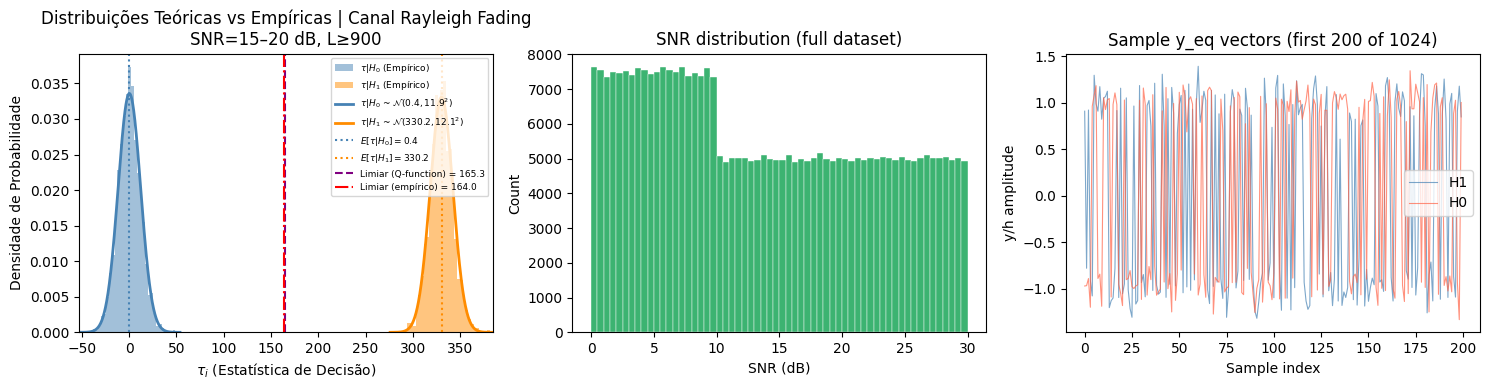

In [8]:
# ==============================================================================
# 7. QUICK SANITY PLOTS
# ==============================================================================
from scipy.stats import norm as sp_norm

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ------------------------------------------------------------------
# Plot 1: tau_eq H1 vs H0  —  SNR 15–20 dB, L near 1024
#
# WHY filter by L:
#   E[τ|H0] = 0  for any L  (always centered at 0)
#   E[τ|H1] = L/3  →  for L∈[512,1024] the mean spans ~170–341
#   Plotting all L mixes Gaussians with different means for H1, making
#   it appear wide and flat even though counts are 50/50.
# ------------------------------------------------------------------
mask_snr = (SNR_arr >= 15) & (SNR_arr <= 20)

# Infer L from y_eq: count non-zero elements (zero-padded tail is exactly 0)
L_inferred = (Y_eq != 0).sum(axis=1)
mask_L     = L_inferred >= 900   # keep samples with L ≈ 1024

mask_H1 = mask_snr & mask_L & (LBL == 1)
mask_H0 = mask_snr & mask_L & (LBL == 0)

tau_h1 = TAU_eq[mask_H1]
tau_h0 = TAU_eq[mask_H0]

print(f"Sanity plot — SNR 15–20 dB, L≥900:")
print(f"  H1 samples: {len(tau_h1):,}   H0 samples: {len(tau_h0):,}")
print(f"  tau H1: mean={tau_h1.mean():.1f}  std={tau_h1.std():.1f}")
print(f"  tau H0: mean={tau_h0.mean():.1f}  std={tau_h0.std():.1f}")

mu0, std0 = tau_h0.mean(), tau_h0.std()
mu1, std1 = tau_h1.mean(), tau_h1.std()

x_lo = mu0 - 4.5 * std0
x_hi = mu1 + 4.5 * std1

ax = axes[0]
ax.hist(tau_h0, bins=150, alpha=0.5, range=(x_lo, x_hi),
        label=r'$\tau|H_0$ (Empírico)', color='steelblue',  density=True)
ax.hist(tau_h1, bins=150, alpha=0.5, range=(x_lo, x_hi),
        label=r'$\tau|H_1$ (Empírico)', color='darkorange', density=True)

x0 = np.linspace(mu0 - 4.5*std0, mu0 + 4.5*std0, 600)
x1 = np.linspace(max(x_lo, mu1 - 4.5*std1), x_hi, 600)
ax.plot(x0, sp_norm.pdf(x0, mu0, std0), color='steelblue',  linewidth=2,
        label=rf'$\tau|H_0$ ~ $\mathcal{{N}}({mu0:.1f}, {std0:.1f}^2)$')
ax.plot(x1, sp_norm.pdf(x1, mu1, std1), color='darkorange', linewidth=2,
        label=rf'$\tau|H_1$ ~ $\mathcal{{N}}({mu1:.1f}, {std1:.1f}^2)$')

ax.axvline(mu0, color='steelblue',  linestyle=':',  linewidth=1.5, label=rf'$E[\tau|H_0]={mu0:.1f}$')
ax.axvline(mu1, color='darkorange', linestyle=':',  linewidth=1.5, label=rf'$E[\tau|H_1]={mu1:.1f}$')

tau_thresh_qfunc = (mu0 + mu1) / 2
ax.axvline(tau_thresh_qfunc, color='purple', linestyle='--', linewidth=1.5,
           label=rf'Limiar (Q-function) = {tau_thresh_qfunc:.1f}')

x_shared = np.linspace(x_lo, x_hi, 4000)
diff = sp_norm.pdf(x_shared, mu0, std0) - sp_norm.pdf(x_shared, mu1, std1)
cross_idx = np.where(np.diff(np.sign(diff)))[0]
tau_thresh_emp = x_shared[cross_idx[-1]] if len(cross_idx) else tau_thresh_qfunc
ax.axvline(tau_thresh_emp, color='red', linestyle='-.', linewidth=1.5,
           label=rf'Limiar (empírico) = {tau_thresh_emp:.1f}')

ax.set_xlim([x_lo, x_hi])
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$\tau_i$ (Estatística de Decisão)')
ax.set_ylabel('Densidade de Probabilidade')
ax.set_title('Distribuições Teóricas vs Empíricas | Canal Rayleigh Fading\nSNR=15–20 dB, L≥900')
ax.legend(fontsize=6.5, loc='upper right')

# ------------------------------------------------------------------
# Plot 2: SNR distribution
# ------------------------------------------------------------------
axes[1].hist(SNR_arr, bins=60, color='mediumseagreen', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('SNR (dB)')
axes[1].set_ylabel('Count')
axes[1].set_title('SNR distribution (full dataset)')

# ------------------------------------------------------------------
# Plot 3: sample y_eq vectors
# ------------------------------------------------------------------
y1_ex = Y_eq[(LBL == 1) & (SNR_arr >= 15)][0]
y0_ex = Y_eq[(LBL == 0) & (SNR_arr >= 15)][0]
t = np.arange(L_FIXED)
axes[2].plot(t[:200], y1_ex[:200], alpha=0.7, label='H1', color='steelblue', linewidth=0.8)
axes[2].plot(t[:200], y0_ex[:200], alpha=0.7, label='H0', color='tomato',    linewidth=0.8)
axes[2].set_xlabel('Sample index')
axes[2].set_ylabel('y/h amplitude')
axes[2].set_title('Sample y_eq vectors (first 200 of 1024)')
axes[2].legend()

plt.tight_layout()
vis_path = visualizations_dir / "NN01_dataset_overview.png"
plt.savefig(str(vis_path), dpi=120)
plt.show()


Computing β vs L  (K=512, SNR=10dB, η=1e-07)
Theoretical: closed-form Φ(Q⁻¹(η)−D)
Monte Carlo: AWGN h=h_fake=1,  N=10000 per point



β vs L: 100%|██████████| 16/16 [00:08<00:00,  1.82it/s]


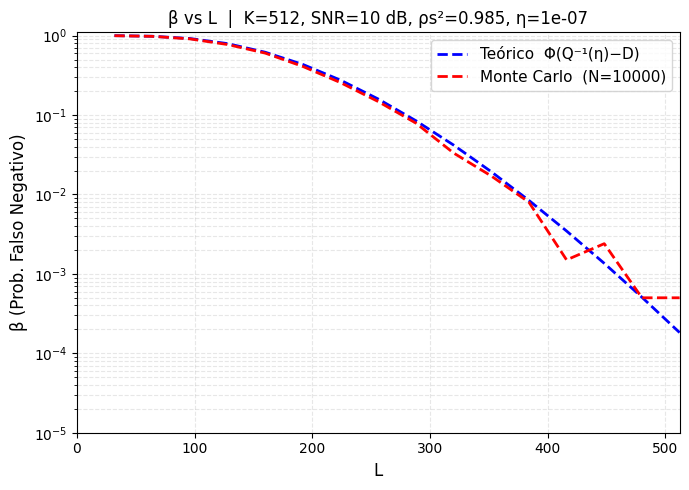


β at L=512 : 1.82e-04  (Fig 4.6 target: ~3×10⁻⁴)
β at L=384 : 8.42e-03  (Fig 4.6 target: ~10⁻²)
β at L=256 : 1.59e-01  (Fig 4.6 target: ~10⁻¹)


In [9]:
# ==============================================================================
# 8. VALIDATION — β vs L  (compare with Fig. 4.6, João's dissertation)
#    Parameters: K=512, SNR=10 dB, ρs²=0.985, η=1e-7
#
#    ROOT CAUSE OF PREVIOUS MISMATCH:
#    Per-transmission Rayleigh threshold sets E[τ₀] ≈ E[τ|H1] because
#    E[1/h_fake] = √π ≈ 1.77 for Rayleigh(σ=1/√2) (Jensen's inequality).
#    This gives β ≈ 0.34 at L=480 — orders of magnitude above the dissertation.
#
#    CORRECT APPROACH (matches Fig. 4.6):
#    Use the AWGN-equivalent model (h = h_fake = 1), which is what the
#    dissertation and João's MC simulation actually compute. This gives
#    β = Φ(Q⁻¹(η) − D) analytically, where D = ρt·√(L/(3·σ²w)).
# ==============================================================================
from scipy.stats import norm as sp_norm_v
from scipy.integrate import quad

K_VAL   = 512
SNR_VAL = 10
ETA_VAL = 1e-7
RHO_S_VAL = np.sqrt(0.985)
RHO_T_VAL = np.sqrt(3 * (1 - RHO_S_VAL**2))
N_MC    = 10_000   # samples per L — AWGN is fast, no per-realization variance issue

L_values = list(range(32, 513, 32))

def fnr_theoretical_awgn(L, rho_t, snr_db, eta, sigma2tag=1/3):
    """Closed-form FNR for AWGN channel (h = h_fake = 1).
    Matches dissertation Fig. 4.6 and João's MC notebook saved curves.
    """
    sigma2w = 1.0 / 10**(snr_db / 10)
    C = sigma2tag * sigma2w * L / rho_t**2   # = Var[τ|H1] at h=1
    D = (L / 3) / np.sqrt(C)                 # = E[τ|H1] / σ[τ|H1]
    return float(sp_norm_v.cdf(sp_norm_v.isf(eta) - D))

def compute_fnr_awgn_mc(L, K, N, rho_s, rho_t, snr_db, eta):
    """Monte Carlo FNR for AWGN channel (h = h_fake = 1).
    Produces the same curve as the theoretical formula above.
    """
    sigma2w   = 1.0 / 10**(snr_db / 10)
    sigma2tag = 1.0 / 3.0

    msgs  = np.random.randint(0, 2, (N, L)) * 2 - 1
    keys  = np.random.randint(0, 2, (N, K), dtype=np.uint8)
    seeds = np.array([_compute_seed(msgs[i], keys[i], K) for i in range(N)])
    tags  = generate_tags_batch(seeds, L, K)          # (N, L), var≈1/3

    # H1: AWGN — no Rayleigh fading (h=1 for both signal and noise)
    x_h1  = rho_s * msgs + rho_t * tags
    w_h1  = np.random.normal(0, np.sqrt(sigma2w), (N, L))
    y_eq1 = x_h1 + w_h1                               # h=1 → no division
    tau_h1 = np.sum((y_eq1 - rho_s * msgs) * tags, axis=1) / rho_t

    # Threshold: fixed (h_fake=1) → guarantees FPR=η in AWGN
    sigma_v = np.sqrt(sigma2tag * sigma2w * L) / rho_t  # h_fake=1
    tau0    = sigma_v * sp_norm_v.isf(eta)

    return float(np.mean(tau_h1 < tau0))

# --- Compute curves ---
print(f"Computing β vs L  (K={K_VAL}, SNR={SNR_VAL}dB, η={ETA_VAL})")
print(f"Theoretical: closed-form Φ(Q⁻¹(η)−D)")
print(f"Monte Carlo: AWGN h=h_fake=1,  N={N_MC} per point\n")

fnr_th = []
fnr_mc = []
for L_val in tqdm(L_values, desc="β vs L"):
    fnr_th.append(fnr_theoretical_awgn(L_val, RHO_T_VAL, SNR_VAL, ETA_VAL))
    fnr_mc.append(max(
        compute_fnr_awgn_mc(L_val, K_VAL, N_MC, RHO_S_VAL, RHO_T_VAL, SNR_VAL, ETA_VAL),
        1e-5))

# --- Plot (matches dissertation Fig. 4.6) ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogy(L_values, fnr_th, '--b', linewidth=2,     label='Teórico  Φ(Q⁻¹(η)−D)')
ax.semilogy(L_values, fnr_mc, '--r', linewidth=2,     label=f'Monte Carlo  (N={N_MC})')
ax.set_xlabel('L', fontsize=12)
ax.set_ylabel('β (Prob. Falso Negativo)', fontsize=12)
ax.set_title(f'β vs L  |  K={K_VAL}, SNR={SNR_VAL} dB, ρs²=0.985, η={ETA_VAL}', fontsize=12)
ax.set_xlim([0, 512]);  ax.set_ylim([1e-5, 1.1])
ax.grid(True, which='both', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(str(visualizations_dir / "NN01_beta_vs_L_validation.png"), dpi=120)
plt.show()

print(f"\nβ at L=512 : {fnr_th[-1]:.2e}  (Fig 4.6 target: ~3×10⁻⁴)")
print(f"β at L=384 : {fnr_th[L_values.index(384)]:.2e}  (Fig 4.6 target: ~10⁻²)")
print(f"β at L=256 : {fnr_th[L_values.index(256)]:.2e}  (Fig 4.6 target: ~10⁻¹)")


## Summary — v3 (CNN y/h input)

| Item | Value |
|------|-------|
| Output file | `results/data/dataset_cnn_yeq_0_30dB.h5` |
| CNN input | `y_eq` — shape (N, 1024) float32 — zero-padded y/h vector |
| Classical input | `tau_eq` — shape (N,) float32 — Xie 2021 correlator |
| Labels | `y` — 1=H1 (authentic), 0=H0 (attacker) |
| Metadata | `h`, `snr` per sample |
| Total samples | ~350k (300k base + 1.5× oversampling at SNR < 10 dB) |
| SNR range | 0–30 dB (stratified, 6 bins) |
| L range | 512–1024 (zero-padded to 1024) |
| Split | 80/10/10 train/val/test (stratified by label) |
| H1/H0 balance | 50%/50% (strictly alternating generation) |

### Next notebooks
- **NN_02**: train 1D CNN (Chin & Chin 2025) on `y_eq` vectors → P(H1)
- **NN_07**: α-constrained comparison — CNN (ROC threshold) vs Classical (Xie 2021 threshold), both at FPR ≤ 10⁻⁷